RESTAURANT RATING ANALYSIS-LEVEL-1

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [ ]:
df=pd.read_csv('/content/sample_data/Dataset  (2).csv')
df.head()

In [ ]:
df.isnull().sum()

,0
Restaurant ID,0
Restaurant Name,0
Country Code,0
City,0
Address,0
Locality,0
Locality Verbose,0
Longitude,0
Latitude,0
Cuisines,9


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null   object 
 15  Switch to order menu 

In [ ]:
df.describe()

,Restaurant ID,Country Code,Longitude,Latitude,Average Cost for two,Price range,Aggregate rating,Votes
count,9.551000e+03,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000
mean,9.051128e+06,18.365616,64.126574,25.854381,1199.210763,1.804837,2.666370,156.909748
std,8.791521e+06,56.750546,41.467058,11.007935,16121.183073,0.905609,1.516378,430.169145
min,5.300000e+01,1.000000,-157.948486,-41.330428,0.000000,1.000000,0.000000,0.000000
25%,3.019625e+05,1.000000,77.081343,28.478713,250.000000,1.000000,2.500000,5.000000
50%,6.004089e+06,1.000000,77.191964,28.570469,400.000000,2.000000,3.200000,31.000000
75%,1.835229e+07,1.000000,77.282006,28.642758,700.000000,2.000000,3.700000,131.000000
max,1.850065e+07,216.000000,174.832089,55.976980,800000.000000,4.000000,4.900000,10934.000000


In [ ]:
df.shape

(9551, 21)

In [ ]:
#Check the distribution of 'Aggregate rating'
rating_distribution = df['Aggregate rating'].value_counts()
print("\nAggregate Rating Distribution:\n", rating_distribution)


Aggregate Rating Distribution:
 Aggregate rating
0.0    2148
3.2     522
3.1     519
3.4     498
3.3     483
3.5     480
3.0     468
3.6     458
3.7     427
3.8     400
2.9     381
3.9     335
2.8     315
4.1     274
4.0     266
2.7     250
4.2     221
2.6     191
4.3     174
4.4     144
2.5     110
4.5      95
2.4      87
4.6      78
4.9      61
2.3      47
4.7      42
2.2      27
4.8      25
2.1      15
2.0       7
1.9       2
1.8       1
Name: count, dtype: int64


In [ ]:
# Class imbalance (percentage distribution)
class_imbalance = df['Aggregate rating'].value_counts(normalize=True) * 100
print("\nClass Imbalance (%):\n", class_imbalance)


Class Imbalance (%):
 Aggregate rating
0.0    22.489792
3.2     5.465396
3.1     5.433986
3.4     5.214114
3.3     5.057062
3.5     5.025652
3.0     4.900010
3.6     4.795309
3.7     4.470736
3.8     4.188043
2.9     3.989111
3.9     3.507486
2.8     3.298084
4.1     2.868810
4.0     2.785049
2.7     2.617527
4.2     2.313894
2.6     1.999791
4.3     1.821799
4.4     1.507696
2.5     1.151712
4.5     0.994660
2.4     0.910899
4.6     0.816668
4.9     0.638677
2.3     0.492095
4.7     0.439745
2.2     0.282693
4.8     0.261753
2.1     0.157052
2.0     0.073291
1.9     0.020940
1.8     0.010470
Name: proportion, dtype: float64


In [ ]:
#Distribution of Categorical Variables
#Country distribution
country_distribution = df['Country Code'].value_counts()
print("\nCountry Code Distribution:\n", country_distribution)

# City Distribution
city_distribution = df['City'].value_counts()
print("\nCity Distribution:\n", city_distribution)

# Cuisines Distribution
cuisines_distribution = df['Cuisines'].value_counts()
print("\nCuisines Distribution:\n", cuisines_distribution)



Country Code Distribution:
 Country Code
1      8652
216     434
215      80
30       60
214      60
189      60
148      40
208      34
14       24
162      22
94       21
184      20
166      20
191      20
37        4
Name: count, dtype: int64

City Distribution:
 City
New Delhi           5473
Gurgaon             1118
Noida               1080
Faridabad            251
Ghaziabad             25
                    ... 
Panchkula              1
Mc Millan              1
Mayfield               1
Macedon                1
Vineland Station       1
Name: count, Length: 141, dtype: int64

Cuisines Distribution:
 Cuisines
North Indian                                             936
North Indian, Chinese                                    511
Chinese                                                  354
Fast Food                                                354
North Indian, Mughlai                                    334
                                                        ... 
Bengali, Fas

In [ ]:
# Identify Top Cuisines and Cities with the Highest Number of Restaurants
# Top 10 Cuisines
top_cuisines = df['Cuisines'].value_counts().head(10)
print("\nTop 10 Cuisines:\n", top_cuisines)

# Top 10 Cities
top_cities = df['City'].value_counts().head(10)
print("\nTop 10 Cities:\n", top_cities)



Top 10 Cuisines:
 Cuisines
North Indian                      936
North Indian, Chinese             511
Chinese                           354
Fast Food                         354
North Indian, Mughlai             334
Cafe                              299
Bakery                            218
North Indian, Mughlai, Chinese    197
Bakery, Desserts                  170
Street Food                       149
Name: count, dtype: int64

Top 10 Cities:
 City
New Delhi       5473
Gurgaon         1118
Noida           1080
Faridabad        251
Ghaziabad         25
Bhubaneshwar      21
Amritsar          21
Ahmedabad         21
Lucknow           21
Guwahati          21
Name: count, dtype: int64


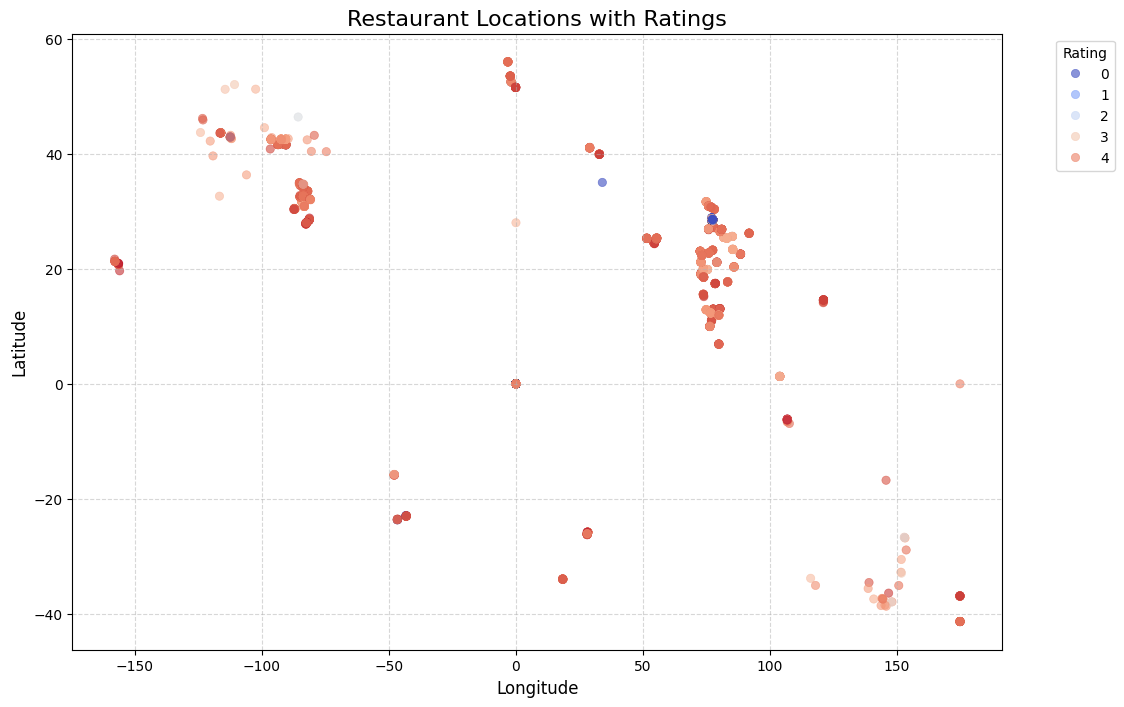

In [ ]:
# Visualize Restaurant Locations on a Scatter Plot
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='Longitude',
    y='Latitude',
    data=df,
    hue='Aggregate rating',
    palette='coolwarm',
    alpha=0.6,
    edgecolor=None
)
plt.title('Restaurant Locations with Ratings', fontsize=16)
plt.xlabel('Longitude', fontsize=12)
plt.ylabel('Latitude', fontsize=12)
plt.legend(title='Rating', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(linestyle='--', alpha=0.5)
plt.show()

In [ ]:
# Analyze Distribution Across Cities or Countries
# City distribution
city_distribution = df['City'].value_counts().head(10)
print("\nTop 10 Cities with the Most Restaurants:\n", city_distribution)


Top 10 Cities with the Most Restaurants:
 City
New Delhi       5473
Gurgaon         1118
Noida           1080
Faridabad        251
Ghaziabad         25
Bhubaneshwar      21
Amritsar          21
Ahmedabad         21
Lucknow           21
Guwahati          21
Name: count, dtype: int64


<ipython-input-13-2fabbe583a91>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=city_distribution.values, y=city_distribution.index, palette="viridis")


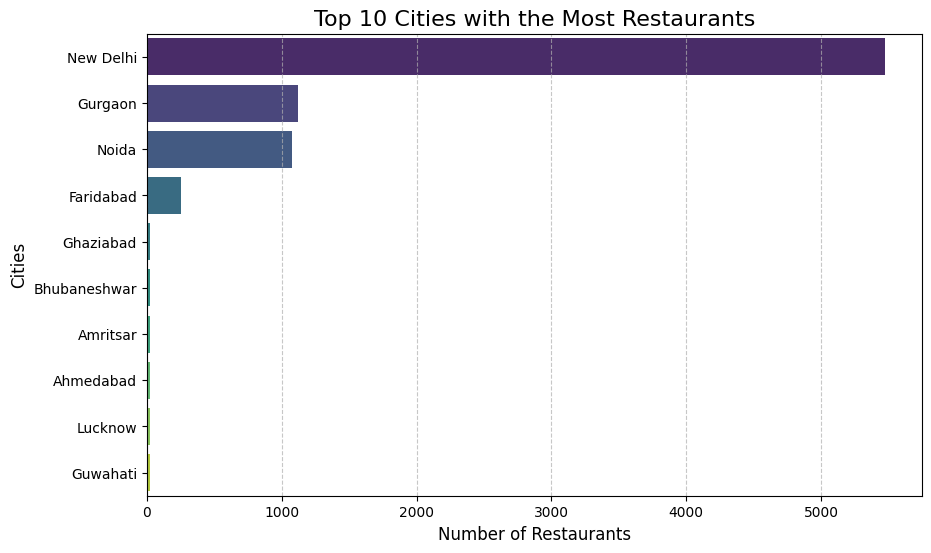

In [ ]:
# Plotting city distribution
plt.figure(figsize=(10, 6))
sns.barplot(x=city_distribution.values, y=city_distribution.index, palette="viridis")
plt.title('Top 10 Cities with the Most Restaurants', fontsize=16)
plt.xlabel('Number of Restaurants', fontsize=12)
plt.ylabel('Cities', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [ ]:

# Country distribution
country_distribution = df['Country Code'].value_counts()
print("\nRestaurant Distribution Across Countries:\n", country_distribution)


Restaurant Distribution Across Countries:
 Country Code
1      8652
216     434
215      80
30       60
214      60
189      60
148      40
208      34
14       24
162      22
94       21
184      20
166      20
191      20
37        4
Name: count, dtype: int64


<ipython-input-15-22439f6e8a58>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


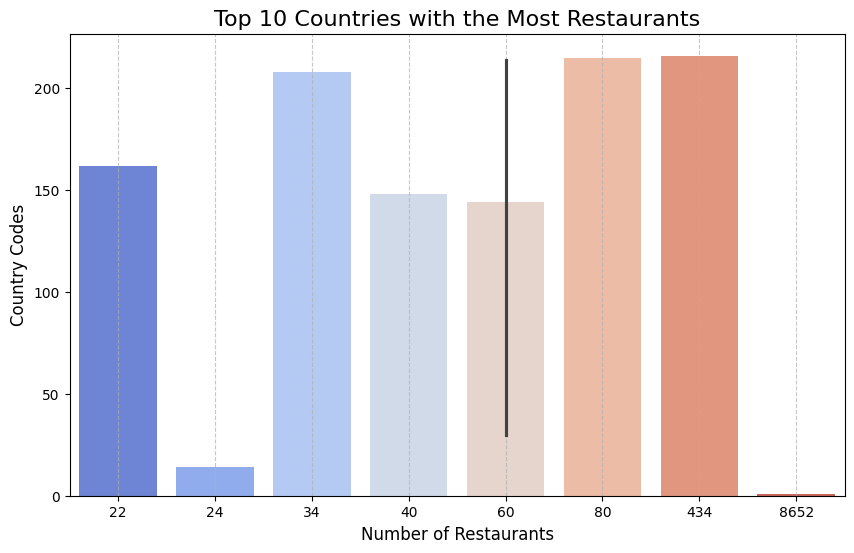

In [ ]:
# Plotting country distribution
plt.figure(figsize=(10, 6))
sns.barplot(
    x=country_distribution.values[:10],
    y=country_distribution.index[:10],
    palette="coolwarm"
)
plt.title('Top 10 Countries with the Most Restaurants', fontsize=16)
plt.xlabel('Number of Restaurants', fontsize=12)
plt.ylabel('Country Codes', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
#  Correlation Between Location and Rating
# Correlation analysis for Latitude, Longitude, and Aggregate Rating
correlation_matrix = df[['Latitude', 'Longitude', 'Aggregate rating']].corr()
print("\nCorrelation Between Location and Rating:\n", correlation_matrix)


Correlation Between Location and Rating:
                   Latitude  Longitude  Aggregate rating
Latitude          1.000000   0.043207          0.000516
Longitude         0.043207   1.000000         -0.116818
Aggregate rating  0.000516  -0.116818          1.000000


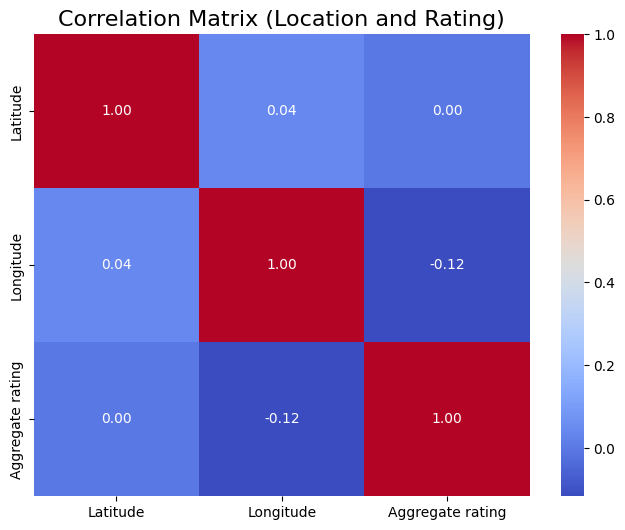

In [ ]:
# Visualizing the correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix (Location and Rating)', fontsize=16)
plt.show()

LEVEL-2   TASK-1

In [ ]:
# Task 1: Calculate percentages
total_restaurants = len(df)
print(total_restaurants)

9551


In [ ]:
# Percentage of restaurants offering table booking and online delivery
table_booking_percentage = (df['Has Table booking'].str.lower() == 'yes').mean() * 100
online_delivery_percentage = (df['Has Online delivery'].str.lower() == 'yes').mean() * 100
print("Percentage of restaurants offering table booking: {:.2f}%".format(table_booking_percentage))
print("Percentage of restaurants offering online delivery: {:.2f}%".format(online_delivery_percentage))

Percentage of restaurants offering table booking: 12.12%
Percentage of restaurants offering online delivery: 25.66%


In [ ]:
# Task 2: Compare average ratings of restaurants with and without table booking
avg_rating_table_booking = df.loc[df['Has Table booking'].str.lower() == 'yes', 'Aggregate rating'].mean()
avg_rating_no_table_booking = df.loc[df['Has Table booking'].str.lower() == 'no', 'Aggregate rating'].mean()
print("Average rating of restaurants with table booking: {:.2f}".format(avg_rating_table_booking))
print("Average rating of restaurants without table booking: {:.2f}".format(avg_rating_no_table_booking))


Average rating of restaurants with table booking: 3.44
Average rating of restaurants without table booking: 2.56


In [ ]:
# Task 3: Analyze online delivery availability across price ranges
online_delivery_by_price_range = (
    df[df['Has Online delivery'].str.lower() == 'yes']
    .groupby('Price range').size() / df.groupby('Price range').size() * 100
)
print("\nOnline delivery availability by price range:")
print(online_delivery_by_price_range)


Online delivery availability by price range:
Price range
1    15.774077
2    41.310633
3    29.190341
4     9.044369
dtype: float64


LEVEL-2   TASK-2

In [ ]:
# Task 1: Determine the most common price range
most_common_price_range = df['Price range'].mode()[0]
print("Most common price range:", most_common_price_range)

Most common price range: 1


In [ ]:
# Task 2: Calculate the average rating for each price range
average_rating_by_price_range = df.groupby('Price range')['Aggregate rating'].mean()
print("\nAverage rating by price range:")
print(average_rating_by_price_range)



Average rating by price range:
Price range
1    1.999887
2    2.941054
3    3.683381
4    3.817918
Name: Aggregate rating, dtype: float64


In [ ]:
# Task 3: Identify the color representing the highest average rating
# Get the price range with the highest average rating
highest_avg_rating_price_range = average_rating_by_price_range.idxmax()
# Find the rating color for the highest average rating price range
highest_avg_rating_color = df.loc[df['Price range'] == highest_avg_rating_price_range, 'Rating color'].mode()[0]
print("\nColor representing the highest average rating:",highest_avg_rating_color)



Color representing the highest average rating: Yellow


LEVEL-2 TASK-3

In [ ]:
# Task 1: Extract additional features
# Length of restaurant name
df['Restaurant Name Length'] = df['Restaurant Name'].str.len()

# Length of address
df['Address Length'] = df['Address'].str.len()

# Task 2: Create new features by encoding categorical variables
# Encode "Has Table booking" as 1 for 'Yes' and 0 for 'No'
df['Has Table Booking'] = df['Has Table booking'].str.lower().map({'yes': 1, 'no': 0})

# Encode "Has Online delivery" as 1 for 'Yes' and 0 for 'No'
df['Has Online Delivery'] = df['Has Online delivery'].str.lower().map({'yes': 1, 'no': 0})

# Display the updated dataset with the new features
print(df[['Restaurant Name', 'Restaurant Name Length', 'Address', 'Address Length', 'Has Table Booking', 'Has Online Delivery']].head())

          Restaurant Name  Restaurant Name Length  \
0        Le Petit Souffle                      16   
1        Izakaya Kikufuji                      16   
2  Heat - Edsa Shangri-La                      22   
3                    Ooma                       4   
4             Sambo Kojin                      11   

                                             Address  Address Length  \
0  Third Floor, Century City Mall, Kalayaan Avenu...              71   
1  Little Tokyo, 2277 Chino Roces Avenue, Legaspi...              67   
2  Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...              56   
3  Third Floor, Mega Fashion Hall, SM Megamall, O...              70   
4  Third Floor, Mega Atrium, SM Megamall, Ortigas...              64   

   Has Table Booking  Has Online Delivery  
0                  1                    0  
1                  1                    0  
2                  1                    0  
3                  0                    0  
4                  1        

LEVEL-3   TASK-1

In [ ]:
# Select relevant features and target
target = 'Aggregate rating'
features = [
    'Country Code', 'City', 'Cuisines', 'Longitude', 'Latitude',
    'Has Table booking', 'Has Online delivery', 'Price range', 'Votes'
]
df = df[features + [target]]

In [ ]:
# Split the dataset into training and testing sets
X = df[features]
y = df[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
# Encode categorical variables for training set
label_encoders = {}
for col in ['City', 'Cuisines', 'Has Table booking', 'Has Online delivery']:
    le = LabelEncoder()
    # Fit the encoder on the training data only and transform the training data
    X_train[col] = le.fit_transform(X_train[col].astype(str))
    label_encoders[col] = le

In [ ]:
# Encode categorical variables for training set
label_encoders = {}
for col in ['City', 'Cuisines', 'Has Table booking', 'Has Online delivery']:
    le = LabelEncoder()
    # Fit the encoder on the training data only and transform the training data
    X_train[col] = le.fit_transform(X_train[col].astype(str))
    label_encoders[col] = le

In [ ]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
# Initialize models
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42, n_estimators=100)
}


In [ ]:
# Train and evaluate each model
results = {}

for name, model in models.items():
    # Train the model
    model.fit(X_train, y_train)

    # Predict on the test set
    y_pred = model.predict(X_test)

    # Evaluate performance
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    # Store results
    results[name] = {
        "MSE": mse,
        "MAE": mae,
        "R^2": r2
    }


In [ ]:
# Convert results to a DataFrame
results_df = pd.DataFrame(results).T
print("Model Performance:\n", results_df)

Model Performance:
                         MSE       MAE       R^2
Linear Regression  1.571358  1.046063  0.309630
Decision Tree      0.177002  0.273626  0.922235
Random Forest      0.094062  0.199117  0.958674


In [ ]:
# Feature importance for Random Forest
if "Random Forest" in models:
    rf_model = models["Random Forest"]
    feature_importances = pd.Series(rf_model.feature_importances_, index=features)
    print("\nFeature Importances (Random Forest):\n", feature_importances.sort_values(ascending=False))



Feature Importances (Random Forest):
 Votes                  0.947948
Longitude              0.014123
Latitude               0.012233
Cuisines               0.011444
City                   0.007382
Price range            0.002853
Country Code           0.002023
Has Online delivery    0.001388
Has Table booking      0.000607
dtype: float64


LEVEL-3 TASK-2

In [ ]:
# Analyze relationship between cuisine type and ratings/votes
cuisine_analysis = df.groupby("Cuisines").agg(
    Average_Rating=("Aggregate rating", "mean"),
    Total_Votes=("Votes", "sum"),
    Count=("Cuisines", "count")
).sort_values(by="Total_Votes", ascending=False)

In [ ]:
# Add a rank column for popularity (based on votes)
cuisine_analysis["Popularity_Rank"] = cuisine_analysis["Total_Votes"].rank(ascending=False)

In [ ]:
# Sort by average rating to identify cuisines with higher ratings
cuisine_analysis_sorted_by_rating = cuisine_analysis.sort_values(by="Average_Rating", ascending=False)

In [ ]:

# Display the top cuisines based on votes and ratings
print("Top cuisines by votes:\n", cuisine_analysis.head())
print("\nTop cuisines by average rating:\n", cuisine_analysis_sorted_by_rating.head())

Top cuisines by votes:
           Average_Rating  Total_Votes  Count  Popularity_Rank
Cuisines                                                     
574             2.888623        53747    334              1.0
343             1.672329        46241    936              2.0
368             2.421722        42012    511              3.0
1085            2.890970        30657    299              4.0
1268            2.042090        21925    354              5.0

Top cuisines by average rating:
           Average_Rating  Total_Votes  Count  Popularity_Rank
Cuisines                                                     
916                  4.9           95      1           1215.0
768                  4.9          249      1            832.5
41                   4.9          322      1            716.0
1770                 4.9         1343      1            239.5
1127                 4.9          548      1            532.5


LEVEL-3 TASK-3

In [ ]:
# Analyze relationship between cuisine type and ratings/votes
cuisine_analysis = df.groupby("Cuisines").agg(
    Average_Rating=("Aggregate rating", "mean"),
    Total_Votes=("Votes", "sum"),
    Count=("Cuisines", "count")
).sort_values(by="Total_Votes", ascending=False)


In [ ]:
# Add a rank column for popularity (based on votes)
cuisine_analysis["Popularity_Rank"] = cuisine_analysis["Total_Votes"].rank(ascending=False)

# Sort by average rating to identify cuisines with higher ratings
cuisine_analysis_sorted_by_rating = cuisine_analysis.sort_values(by="Average_Rating", ascending=False)

# Display the top cuisines based on votes and ratings
print("Top cuisines by votes:\n", cuisine_analysis.head())
print("\nTop cuisines by average rating:\n", cuisine_analysis_sorted_by_rating.head())

Top cuisines by votes:
           Average_Rating  Total_Votes  Count  Popularity_Rank
Cuisines                                                     
574             2.888623        53747    334              1.0
343             1.672329        46241    936              2.0
368             2.421722        42012    511              3.0
1085            2.890970        30657    299              4.0
1268            2.042090        21925    354              5.0

Top cuisines by average rating:
           Average_Rating  Total_Votes  Count  Popularity_Rank
Cuisines                                                     
916                  4.9           95      1           1215.0
768                  4.9          249      1            832.5
41                   4.9          322      1            716.0
1770                 4.9         1343      1            239.5
1127                 4.9          548      1            532.5


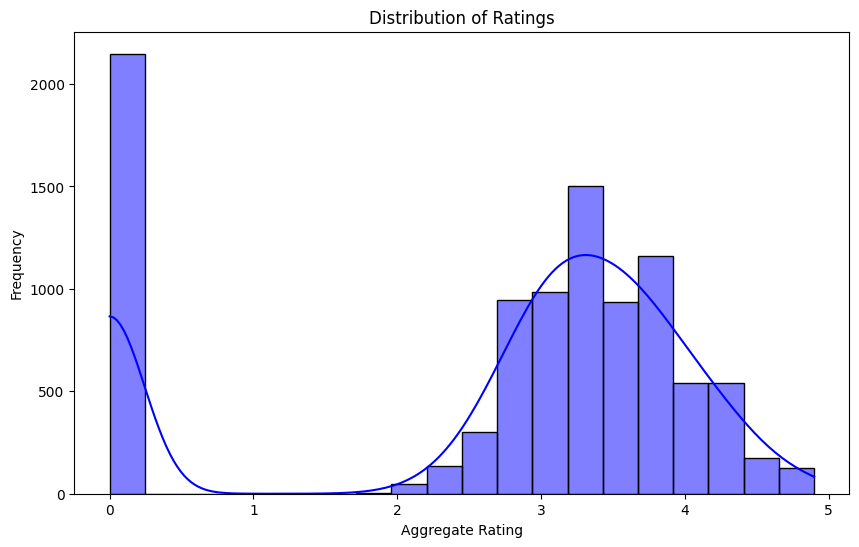

In [ ]:
# Visualizations
# 1. Distribution of ratings
plt.figure(figsize=(10, 6))
sns.histplot(df['Aggregate rating'], bins=20, kde=True, color='blue')
plt.title('Distribution of Ratings')
plt.xlabel('Aggregate Rating')
plt.ylabel('Frequency')
plt.show()

<ipython-input-71-c24556214f58>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cuisine_avg_ratings.index, y=cuisine_avg_ratings['Average_Rating'], palette='viridis')


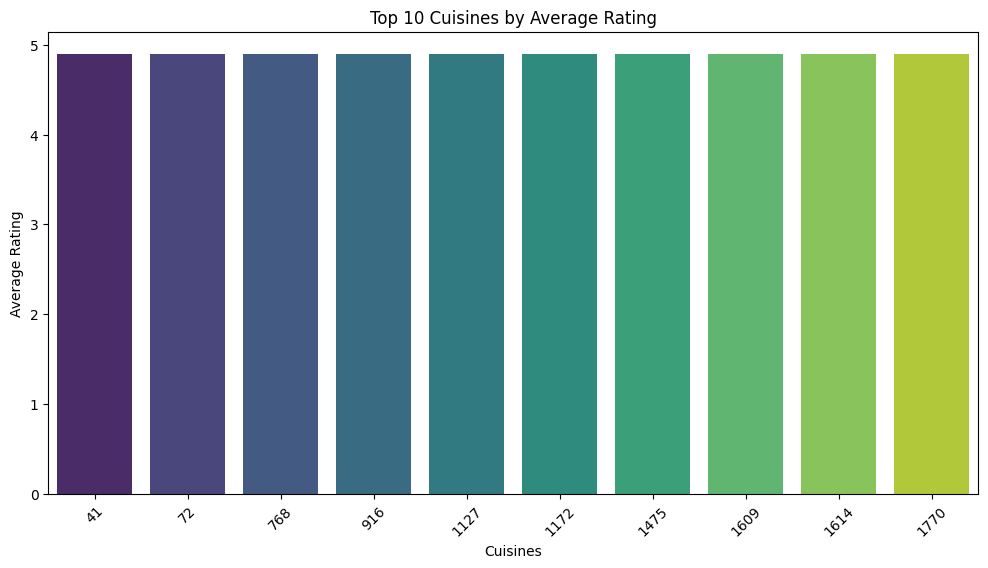

In [ ]:
# 2. Average ratings of different cuisines
cuisine_avg_ratings = cuisine_analysis.sort_values(by='Average_Rating', ascending=False).head(10)
plt.figure(figsize=(12, 6))
sns.barplot(x=cuisine_avg_ratings.index, y=cuisine_avg_ratings['Average_Rating'], palette='viridis')
plt.title('Top 10 Cuisines by Average Rating')
plt.xlabel('Cuisines')
plt.ylabel('Average Rating')
plt.xticks(rotation=45)
plt.show()


<ipython-input-73-aa947cb64ba7>:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=city_avg_ratings.index, y=city_avg_ratings['Average_Rating'], palette='magma')


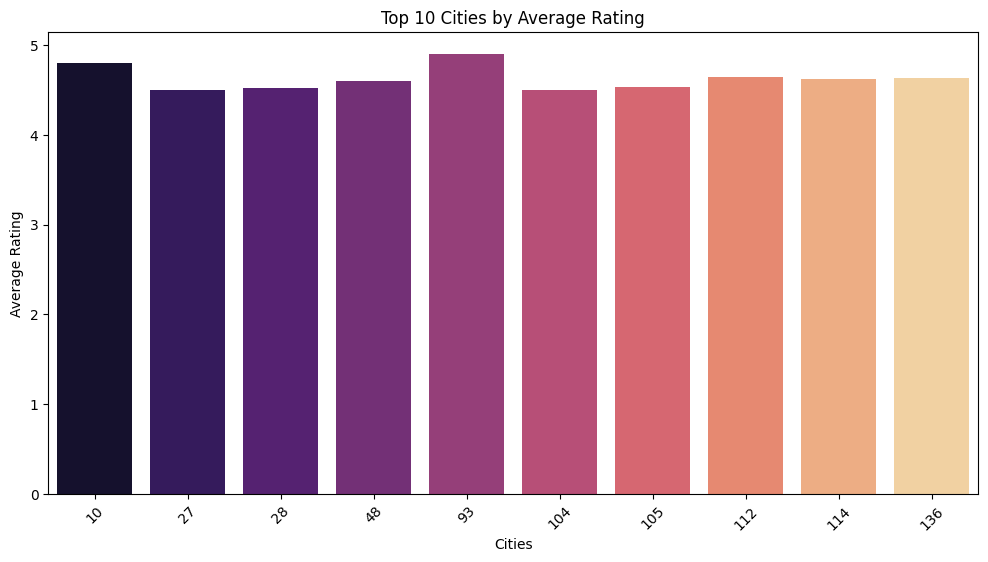

In [ ]:
# 3. Average ratings of different cities
city_analysis = df.groupby("City").agg(
    Average_Rating=("Aggregate rating", "mean"),
    Total_Votes=("Votes", "sum")
).sort_values(by="Average_Rating", ascending=False)
city_avg_ratings = city_analysis.head(10)
plt.figure(figsize=(12, 6))
sns.barplot(x=city_avg_ratings.index, y=city_avg_ratings['Average_Rating'], palette='magma')
plt.title('Top 10 Cities by Average Rating')
plt.xlabel('Cities')
plt.ylabel('Average Rating')
plt.xticks(rotation=45)
plt.show()

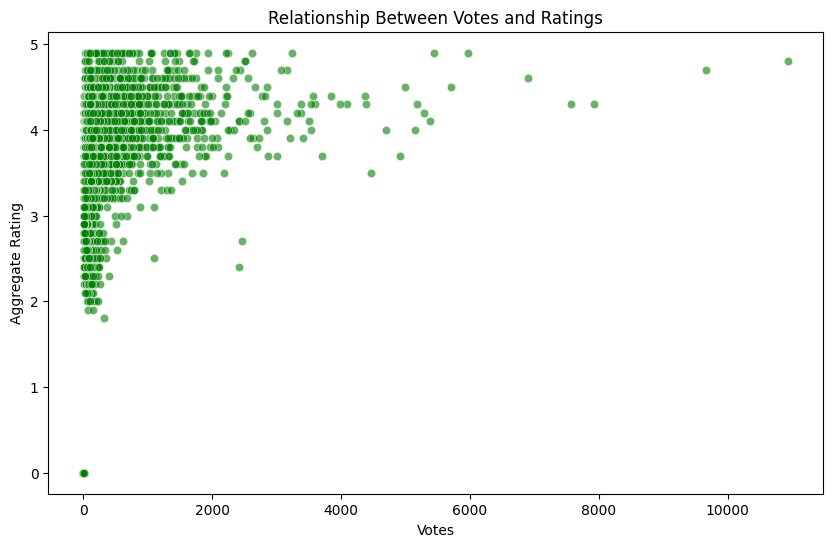

In [ ]:
# 4. Relationship between votes and ratings
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df['Votes'], y=df['Aggregate rating'], alpha=0.6, color='green')
plt.title('Relationship Between Votes and Ratings')
plt.xlabel('Votes')
plt.ylabel('Aggregate Rating')
plt.show()

<ipython-input-77-29e933ffdf24>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df['Price range'], y=df['Aggregate rating'], palette='coolwarm')


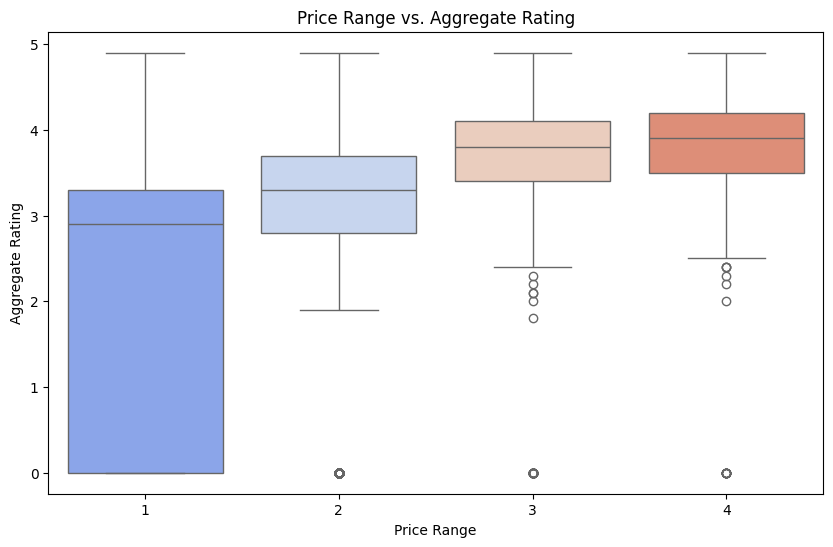

In [ ]:
# 5. Price range vs. ratings
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['Price range'], y=df['Aggregate rating'], palette='coolwarm')
plt.title('Price Range vs. Aggregate Rating')
plt.xlabel('Price Range')
plt.ylabel('Aggregate Rating')
plt.show()
